(06-34-factor-zoo)=

# De factor zoo

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 2011–2023, van Cochrane's presidentiële rede tot de replicatiestudie van
Jensen, Kelly en Pedersen.

**Wat we al weten.** [](#05-33-fama-vs-shiller) sloot het pluralistische tijdvak af
met twee theorieën voor dezelfde feiten: discontovoeten die variëren, door risico of
door vergissing. In de cross-sectie was het beeld nog rommeliger. Sinds
[](#03-16-vroege-anomalieen) stapelden de kenmerken die rendementen voorspellen zich
op, [](#04-25-industrie) liet zien hoe met duizenden gelijktijdige toetsen om te gaan
als het om fondsen gaat, en [](#05-26-sdf-unificatie) gaf de taal om te vragen of een
nieuwe factor iets toevoegt *gegeven* de oude.

**Welke vraag staat open.** Hoeveel van de honderden gepubliceerde voorspellers van
rendementen zijn echt, en waarom verzwakken ze zodra ze gepubliceerd zijn?
```

## Overzicht

In zijn presidentiële rede voor de American Finance Association vatte John Cochrane
in 2011 de toestand van de cross-sectie in één zin samen: "We also thought that the
cross-section of expected returns came from the CAPM. Now we have a zoo of new
factors" {cite}`Cochrane2011`. Het woord bleef hangen. Volgens Santa-Clara waren er in
2011 meer dan driehonderd gepubliceerde kenmerken die rendementen in de cross-sectie
voorspelden {cite}`SantaClara2026`, en {cite:t}`HarveyLiuZhu2016` telden er in hun
eigen catalogus 316. De *factor zoo* (de verzameling van honderden gepubliceerde
factoren en anomalieën, waarvan niemand weet hoeveel er onafhankelijk zijn) is het
logische eindpunt van motief 1: als gemiddelde rendementen slecht gemeten zijn, levert
elke nieuwe dataset en elke nieuwe definitie kandidaten op die "significant" lijken.

Deze lecture definieert het tijdvak aan de hand van drie antwoorden op dezelfde vraag.
Het eerste is statistisch: {cite:t}`HarveyLiuZhu2016` betoogden dat een nieuwe factor
"needs to clear a much higher hurdle, with a t-statistic greater than 3.0". Het tweede
is empirisch: {cite:t}`McLeanPontiff2016` vonden dat de rendementen van 97
voorspellers "26% lower out-of-sample and 58% lower post-publication" zijn, en
{cite:t}`HouXueZhang2020` vonden dat de meeste van 452 anomalieën niet overleven zodra
microcaps weinig gewicht krijgen. Het derde is een tegenreactie:
{cite:t}`ChenZimmermann2022` publiceerden open code die de gepubliceerde voorspellers
reproduceert, en {cite:t}`JensenKellyPedersen2023` concludeerden met een Bayesiaans
model dat "the majority of asset pricing factors (i) can be replicated". Santa-Clara
zet de vraag die daartussen openligt op zijn lijst van dingen die we niet weten:
"why published anomalies decay, and by how much" {cite}`SantaClara2026`.

De epistemische status is motief 3 op zijn scherpst: geen theorie die wordt getoetst, maar
een verzameling feiten waarover de discussie gaat hoeveel het er zijn. De factormodellen
van {cite:t}`FamaFrench2015` en {cite:t}`HouXueZhang2015` beschrijven de dierentuin met een
handvol factoren, elk een keuze voor de SDF uit [](#05-26-sdf-unificatie). Na een
handberekening, de theorie en een simulatie repliceren we op de 212 voorspellers van Chen
en Zimmermann de verzwakking van McLean en Pontiff, de drempels van Harvey, Liu en Zhu, en
de alfa's ten opzichte van vijf factoren plus momentum.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Neem een vakgebied met driehonderd onderzoekers. Elk van hen heeft een
database met rendementen en een idee, en elk idee laat zich op tien manieren
uitwerken: een andere definitie van winst, een andere herbalanceringsmaand, gelijk of
naar marktwaarde gewogen. Stel verder dat geen enkel idee iets voorspelt. Toch vindt
ongeveer een op de veertig uitwerkingen een resultaat dat de gebruikelijke drempel
haalt, simpelweg door toeval. Tijdschriften publiceren die resultaten, en de rest
verdwijnt in een la. Wie de tijdschriften leest, ziet een literatuur vol significante
voorspellers.

Wat gebeurt er met zo'n voorspeller na publicatie? Het toeval dat hem in de steekproef
significant maakte, komt niet terug. Buiten de steekproef is zijn gemiddelde rendement
gemiddeld nul. Voor de lezer ziet dat eruit als een anomalie die "verdwenen" is, terwijl
er nooit iets was. Dat is de *winner's curse* (de vloek van de winnaar: wie selecteert
op een hoge schatting, selecteert ook op een gunstige meetfout).

Is een voorspeller wél echt, een patroon dat beleggers over het hoofd zien, dan lezen
hedgefondsen het artikel en handelen erop tot het niet meer loont: ook dan zakt het
rendement na publicatie, maar omdat de markt heeft geleerd. Is het een beloning voor
risico, dan kan de premie dalen doordat meer beleggers dat risico willen dragen.

McLean en Pontiff zagen dat de klok deze verhalen deels scheidt. Tussen het
einde van de steekproef van een artikel en de publicatie ervan kent de markt het
resultaat nog niet, maar het toeval uit de steekproef is al weg. Een daling in die
tussenperiode is dus statistiek; een extra daling na publicatie is leren. Santa-Clara
vat hun bevinding samen als "the returns to a published predictor fall by about a
quarter out of sample and by well over half after publication", en voegt eraan toe dat
we de verdeling tussen arbitrage en datamining niet kennen, terwijl de consequenties
verschillen: "if it is arbitrage, factor investing is self-defeating at scale; if it is
mining, most of the literature is noise" {cite}`SantaClara2026`.

Wat volgt daaruit voor het onderzoek? Een hogere drempel, omdat een t-waarde van twee na
honderden pogingen weinig zegt. En *shrinkage* (krimpen: een schatting naar een
gemeenschappelijk gemiddelde trekken, met een gewicht dat afhangt van hoe ruisig ze is):
een gemeten rendement van één procent per maand is waarschijnlijk een kleinere echte
premie met een gunstige meetfout. Hoe meer factoren bekend zijn, hoe beter bekend is wat
een redelijk vermoeden is; daarom kan de omvang van de dierentuin het bewijs voor
afzonderlijke factoren ook sterker maken.

## Toy-voorbeeld: tien kandidaat-signalen en één verwacht rendement

### Tien signalen, vier procedures

Een onderzoeker toetst tien signalen A tot en met J. Van elk signaal kent hij de
$t$-waarde van het gemiddelde long-short-rendement. Wij weten, en hij niet, dat alleen A
een echte premie heeft; de andere negen zijn ruis. De getallen zijn zo gekozen dat de
procedures van elkaar verschillen: dat vier van de negen nulsignalen een $t$ boven 2,4
halen, is onder onafhankelijkheid zeldzaam, maar het is precies wat een zoektocht over
varianten van één idee oplevert.

Tweezijdige p-waarden volgen uit $p = 2\,(1 - \Phi(|t|))$ met een normale tabel. Gesorteerd
van klein naar groot, met rang $j$:

| rang $j$ | signaal | $t$ | $p$ | Bonferroni $0{,}05/10$ | Holm $0{,}05/(11-j)$ | BH $0{,}05\,j/10$ | BHY $0{,}05\,j/(10 \cdot 2{,}929)$ |
|---|---|---|---|---|---|---|---|
| 1 | A | 4,10 | 0,00004 | 0,00500 | 0,00500 | 0,005 | 0,00171 |
| 2 | B | 2,79 | 0,00527 | 0,00500 | 0,00556 | 0,010 | 0,00341 |
| 3 | C | 2,70 | 0,00693 | 0,00500 | 0,00625 | 0,015 | 0,00512 |
| 4 | D | 2,45 | 0,01429 | 0,00500 | 0,00714 | 0,020 | 0,00683 |
| 5 | E | 2,20 | 0,02781 | 0,00500 | 0,00833 | 0,025 | 0,00854 |
| 6 | F | 1,60 | 0,10960 | 0,00500 | 0,01000 | 0,030 | 0,01024 |
| 7 | J | −1,30 | 0,19360 | 0,00500 | 0,01250 | 0,035 | 0,01195 |
| 8 | G | 1,10 | 0,27133 | 0,00500 | 0,01667 | 0,040 | 0,01366 |
| 9 | H | 0,80 | 0,42371 | 0,00500 | 0,02500 | 0,045 | 0,01537 |
| 10 | I | −0,50 | 0,61708 | 0,00500 | 0,05000 | 0,050 | 0,01707 |

**Naïef** ($p \le 0{,}05$, dus $|t| > 1{,}96$): A tot en met E, vijf ontdekkingen, waarvan vier
onterecht. **$t > 3$**: alleen A. **Bonferroni** vergelijkt elke $p$ met $0{,}05/10 = 0{,}005$,
wat overeenkomt met $|t| > 2{,}807$: alleen A, want B mist met $0{,}00527$ net. **Holm** loopt
van boven naar beneden en stopt bij de eerste mislukking: A haalt $0{,}005$, B haalt
$0{,}05/9 = 0{,}00556$, C mist $0{,}05/8 = 0{,}00625$. Twee ontdekkingen, A en B.
**Benjamini-Hochberg** zoekt de *grootste* rang $j$ met $p_{(j)} \le 0{,}05\,j/10$: bij D is
$0{,}01429 \le 0{,}020$, bij E is $0{,}02781 > 0{,}025$, en daarna haalt geen enkele rang de
grens meer. Vier ontdekkingen, A tot en met D. **BHY** deelt die grenzen door
$c(10) = 1 + \tfrac12 + \dots + \tfrac1{10} = 2{,}929$: A haalt $0{,}00171$, maar geen enkele
hogere rang haalt zijn grens, dus één ontdekking.

Bonferroni en Holm beperken de kans op *ook maar één* onterechte ontdekking;
Benjamini-Hochberg beperkt het verwachte *aandeel* onterechte ontdekkingen en accepteert
hier drie nulsignalen; BHY doet hetzelfde, maar blijft geldig als signalen afhankelijk
zijn, zoals varianten van één idee altijd zijn.

In [2]:
def multiple_testing(t, q=0.05):
    """Two-sided rejections of H0: mean = 0 for a vector of t-statistics (normal p-values).

    Columns: naive (p <= q), |t| > 3, Bonferroni, Holm (step-down),
    Benjamini-Hochberg and Benjamini-Hochberg-Yekutieli (step-up).
    """
    # TODO: naar hap.stats (multiple testing corrections)
    t = np.asarray(t, dtype=float)
    M = t.size
    p = 2 * stats.norm.sf(np.abs(t))
    order = np.argsort(p)
    ranks = np.arange(1, M + 1)
    p_sorted = p[order]

    def step_up(thresholds):
        passed = np.nonzero(p_sorted <= thresholds)[0]
        k = passed.max() + 1 if passed.size else 0
        reject = np.zeros(M, dtype=bool)
        reject[order[:k]] = True
        return reject

    holm = np.zeros(M, dtype=bool)
    holm[order[np.cumprod(p_sorted <= q / (M - ranks + 1)).astype(bool)]] = True
    c_M = np.sum(1.0 / ranks)
    return pd.DataFrame({
        "naief": p <= q,
        "|t| > 3": np.abs(t) > 3,
        "Bonferroni": p <= q / M,
        "Holm": holm,
        "BH": step_up(q * ranks / M),
        "BHY": step_up(q * ranks / (M * c_M)),
    })


t_toy = pd.Series([4.10, 2.79, 2.70, 2.45, 2.20, 1.60, 1.10, 0.80, -0.50, -1.30], index=list("ABCDEFGHIJ"))
p_hand = pd.Series([0.00004, 0.00527, 0.00693, 0.01429, 0.02781, 0.10960, 0.27133, 0.42371, 0.61708, 0.19360],
                   index=t_toy.index)
p_code = pd.Series(2 * stats.norm.sf(t_toy.abs()), index=t_toy.index)

toy_tests = multiple_testing(t_toy).set_index(t_toy.index)
discoveries = {col: "".join(toy_tests.index[toy_tests[col]]) for col in toy_tests}
print("p-waarden gelijk aan de tabel (5 decimalen):", np.allclose(p_code, p_hand, atol=5e-6))
print("Bonferroni-drempel |t| >", round(stats.norm.isf(0.025 / 10), 3), "; c(10) =", round(np.sum(1 / np.arange(1, 11)), 3))
print("ontdekkingen:", discoveries)
assert discoveries == {"naief": "ABCDE", "|t| > 3": "A", "Bonferroni": "A", "Holm": "AB", "BH": "ABCD", "BHY": "A"}
toy_tests.assign(t=t_toy, p=p_code.round(5))

p-waarden gelijk aan de tabel (5 decimalen): True
Bonferroni-drempel |t| > 2.807 ; c(10) = 2.929
ontdekkingen: {'naief': 'ABCDE', '|t| > 3': 'A', 'Bonferroni': 'A', 'Holm': 'AB', 'BH': 'ABCD', 'BHY': 'A'}


,naief,|t| > 3,Bonferroni,Holm,BH,BHY,t,p
A,True,True,True,True,True,True,4.10,0.00004
B,True,False,False,True,True,False,2.79,0.00527
C,True,False,False,False,True,False,2.70,0.00693
D,True,False,False,False,True,False,2.45,0.01429
E,True,False,False,False,False,False,2.20,0.02781
F,False,False,False,False,False,False,1.60,0.10960
G,False,False,False,False,False,False,1.10,0.27133
H,False,False,False,False,False,False,0.80,0.42371
I,False,False,False,False,False,False,-0.50,0.61708
J,False,False,False,False,False,False,-1.30,0.19360


### Eén gepubliceerd rendement, teruggetrokken naar de dierentuin

Een artikel rapporteert een long-short-rendement van $\hat\alpha = 1\%$ per maand met
$t = 2{,}5$. De standaardfout is dus $s = 1/2{,}5 = 0{,}4\%$. Wat is het verwachte rendement
na publicatie, als er geen arbitrage is?

Stel dat de ware premies van alle signalen die onderzoekers proberen, verdeeld zijn als
$\alpha \sim \mathcal{N}(0, \tau^2)$ met $\tau = 0{,}4\%$: de meeste ideeën leveren weinig op,
een enkele veel. Dan zegt de formule die we hieronder bewijzen
({prf:ref}`thm-factor-zoo-shrinkage`)

$$
\E[\alpha \mid \hat\alpha] = \frac{\tau^2}{\tau^2 + s^2}\,\hat\alpha
= \frac{0{,}16}{0{,}16 + 0{,}16} \times 1\% = 0{,}5\%,
\qquad
\SD(\alpha \mid \hat\alpha) = \sqrt{\frac{\tau^2 s^2}{\tau^2 + s^2}} = \sqrt{0{,}08}\,\% = 0{,}283\%.
$$

Het verwachte rendement na publicatie is de helft van het gepubliceerde. De kans dat de
premie positief is, is $\Phi(0{,}5/0{,}283) = \Phi(1{,}768) = 0{,}961$: waarschijnlijk echt,
maar half zo groot. Denkt men dat premies typisch kleiner zijn, $\tau = 0{,}2\%$, dan wordt
de krimpfactor $0{,}04/(0{,}04 + 0{,}16) = 0{,}2$ en het verwachte rendement $0{,}2\%$. Het
antwoord hangt dus af van wat de rest van de dierentuin zegt over $\tau$. Merk op dat de
publicatieselectie in deze berekening niet voorkomt; waarom dat mag, staat in
{prf:ref}`cor-factor-zoo-selectie`.

In [3]:
alpha_pub, t_pub = 0.01, 2.5
s_pub = alpha_pub / t_pub
rows = {}
for tau in (0.004, 0.002):
    shrink = tau**2 / (tau**2 + s_pub**2)
    post_mean, post_sd = shrink * alpha_pub, np.sqrt(tau**2 * s_pub**2 / (tau**2 + s_pub**2))
    rows[f"tau = {tau:.1%}"] = {"krimpfactor": shrink, "E[alfa | schatting] (%)": 100 * post_mean,
                                "SD posterior (%)": 100 * post_sd, "P(alfa > 0)": stats.norm.cdf(post_mean / post_sd)}
toy_bayes = pd.DataFrame(rows).T
assert np.allclose(toy_bayes.loc["tau = 0.4%", ["krimpfactor", "E[alfa | schatting] (%)"]], [0.5, 0.5])
assert np.isclose(toy_bayes.loc["tau = 0.2%", "E[alfa | schatting] (%)"], 0.2)
toy_bayes.round(4)

,krimpfactor,E[alfa | schatting] (%),SD posterior (%),P(alfa > 0)
tau = 0.4%,0.5,0.5,0.2828,0.9615
tau = 0.2%,0.2,0.2,0.1789,0.8682


## Theorie

### Opzet en notatie

Er zijn $M$ signalen $i = 1, \dots, M$. Signaal $i$ is een long-short-portefeuille met
maandrendement $r_{i,t+1}$; we noemen het ware gemiddelde $\alpha_i$ (de alfa ten opzichte
van het "nulmodel" dat geen premie verwacht, of ten opzichte van een factormodel als dat
wordt vermeld), de schatting over $T_i$ maanden $\hat\alpha_i$, de standaardfout $s_i$ en
$t_i = \hat\alpha_i/s_i$. In grote steekproeven is $t_i \approx \mathcal{N}(\delta_i, 1)$ met
$\delta_i = \alpha_i/s_i$ de verwachte $t$-waarde, en $p_i = 2(1-\Phi(|t_i|))$. De
nulhypothese $H_i$ is $\alpha_i = 0$; $\mathcal{I}_0$ is de verzameling ware nulhypothesen,
met $M_0 = |\mathcal{I}_0|$ elementen.

Een procedure verwerpt een verzameling hypothesen. Met $V$ het aantal onterechte en $R$ het
totale aantal verwerpingen definiëren we

```{math}
:label: eq-factor-zoo-fwer-fdr
\mathrm{FWER} = \Pr(V \ge 1),
\qquad
\mathrm{FDR} = \E\!\left[\frac{V}{\max(R, 1)}\right].
```

De *family-wise error rate* (FWER, de kans op minstens één onterechte ontdekking) is de
strenge maat; de *false discovery rate* (FDR, het verwachte aandeel onterechte
ontdekkingen) is de milde. Omdat $V/\max(R,1) \le \mathbf{1}\{V \ge 1\}$, is
$\mathrm{FDR} \le \mathrm{FWER}$: wie de FWER beheerst, beheerst ook de FDR.

### Bonferroni en Holm: de kans op één vergissing

*Waarom zou dit waar zijn?* De kans op een vereniging van gebeurtenissen is nooit groter
dan de som van de kansen, hoe ze ook samenhangen. Wie elke toets op niveau $q/M$ doet,
houdt de kans op een onterechte ontdekking dus onder $q$, zonder iets over afhankelijkheid
te weten. Holm merkte op dat die som alleen over de ware nulhypothesen hoeft te lopen, en
dat er daarvan hoogstens $M - j + 1$ over zijn zolang de eerste $j - 1$ verwerpingen
terecht waren.

:::{prf:theorem} Bonferroni en Holm
:label: thm-factor-zoo-holm

Laat de p-waarden van de ware nulhypothesen voldoen aan $\Pr(p_i \le u) \le u$ voor alle
$u \in [0,1]$, met willekeurige afhankelijkheid tussen alle p-waarden.

1. **Bonferroni.** Verwerp $H_i$ als $p_i \le q/M$. Dan is $\mathrm{FWER} \le q M_0/M \le q$.
2. **Holm** {cite}`Holm1979`. Orden $p_{(1)} \le \dots \le p_{(M)}$ en verwerp
   $H_{(1)}, \dots, H_{(k)}$ met $k$ de grootste index waarvoor
   $p_{(j)} \le q/(M - j + 1)$ voor *alle* $j \le k$. Dan is $\mathrm{FWER} \le q$, en Holm
   verwerpt alles wat Bonferroni verwerpt.
:::

:::{prf:proof}
(1) $\Pr(V \ge 1) = \Pr\big(\bigcup_{i \in \mathcal{I}_0}\{p_i \le q/M\}\big) \le \sum_{i\in\mathcal{I}_0} q/M = q M_0/M$.

(2) Laat $i^\ast$ de ware nul met de kleinste p-waarde zijn, en $j^\ast$ haar rang in de
geordende rij. Vóór haar staan hoogstens $M - M_0$ p-waarden, dus $j^\ast \le M - M_0 + 1$.
Een onterechte verwerping betekent dat Holm tot minstens rang $j^\ast$ komt, dus
$p_{i^\ast} \le q/(M - j^\ast + 1) \le q/M_0$. Daarom
$\Pr(V \ge 1) \le \Pr\big(\min_{i \in \mathcal{I}_0} p_i \le q/M_0\big) \le M_0 \cdot q/M_0 = q$.
Omdat $q/(M-j+1) \ge q/M$, haalt elke Bonferroni-verwerping ook haar Holm-grens, en een
Bonferroni-verwerping op rang $j$ impliceert dat alle kleinere p-waarden hun (lagere)
Holm-grens halen. $\square$
:::

### Benjamini-Hochberg-Yekutieli: het aandeel vergissingen onder afhankelijkheid

*Waarom zou dit waar zijn?* De procedure van Benjamini en Hochberg uit
{prf:ref}`thm-industrie-bh` beperkt het aandeel onterechte ontdekkingen tot $q$, maar het
bewijs gebruikte onafhankelijkheid. Twintig varianten van waarde worden echter tegelijk
"significant" of niet, en zo'n klont nulsignalen kan de stapsgewijze procedure over een
grens duwen. Benjamini en Yekutieli lieten zien dat
het ergste geval te beheersen is door $q$ te delen door een logaritmische factor.

:::{prf:theorem} Benjamini-Hochberg-Yekutieli
:label: thm-factor-zoo-bhy

Laat $c(M) = \sum_{j=1}^{M} 1/j$ en $q' = q/c(M)$. Verwerp $H_{(1)},\dots,H_{(k)}$ met
$k = \max\{j : p_{(j)} \le q' j/M\}$. Als de p-waarden van de ware nulhypothesen voldoen aan
$\Pr(p_i \le u) \le u$, bij *willekeurige* afhankelijkheid, dan is
$\mathrm{FDR} \le q M_0/M \le q$ {cite}`BenjaminiYekutieli2001`.
:::

:::{prf:proof}
:class: dropdown

Een step-up-procedure die $R = k$ hypothesen verwerpt, verwerpt precies de $H_i$ met
$p_i \le q'k/M$ (alle p-waarden tot rang $k$ halen die grens, en geen enkele hogere rang
haalt zijn eigen grens, dus zeker niet de lagere grens $q'k/M$). Daarom is

$$
\mathrm{FDR} = \sum_{i \in \mathcal{I}_0} \E\!\left[\frac{\mathbf{1}\{p_i \le q' R/M\}}{R}\,\mathbf{1}\{R \ge 1\}\right].
$$

Houd $i$ vast, schrijf $p = p_i$, en laat $R = r \ge 1$. Met
$1/r = \sum_{k=r}^{M-1}\big(\tfrac1k - \tfrac1{k+1}\big) + \tfrac1M$ en
$\mathbf{1}\{p \le q'r/M\} \le \mathbf{1}\{p \le q'k/M\}$ voor $k \ge r$ geldt

$$
\frac{\mathbf{1}\{p \le q' r/M\}}{r}
\le \sum_{k=1}^{M-1}\Big(\frac1k - \frac1{k+1}\Big)\mathbf{1}\{p \le q'k/M\} + \frac1M\,\mathbf{1}\{p \le q'\}.
$$

De rechterkant hangt niet meer van $R$ af, dus ook niet van de afhankelijkheid tussen
$p$ en de andere p-waarden. Neem verwachtingen en gebruik $\Pr(p \le u) \le u$ en
$\big(\tfrac1k - \tfrac1{k+1}\big)k = \tfrac1{k+1}$:

$$
\E\!\left[\frac{\mathbf{1}\{p \le q'R/M\}}{R}\right]
\le \frac{q'}{M}\Big(\sum_{k=1}^{M-1}\frac{1}{k+1} + 1\Big) = \frac{q'\,c(M)}{M} = \frac{q}{M}.
$$

Sommeren over de $M_0$ ware nulhypothesen geeft $\mathrm{FDR} \le qM_0/M$. $\square$
:::

De prijs van robuustheid is groot: bij $M = 316$ is $c(M) = 6{,}33$. Harvey, Liu en Zhu
catalogiseerden 316 factoren uit 313 artikelen en berekenden per jaar sinds 1967 welke
drempel de procedures hadden opgelegd. In de bespreking van hun figuur 3: "For Bonferroni,
the benchmark t-statistic starts at 1.96 and increases to 3.78 by 2012"; BHY stabiliseert
rond 3,39 bij een FDR van 1% en ligt op 2,78 bij 5%. Hun vuistregel is "about 2.8", in de
samenvatting afgerond tot een $t$-waarde boven 3,0 {cite}`HarveyLiuZhu2016`. Omdat
ongepubliceerde toetsen ontbreken, zijn dat ondergrenzen.

### Publicatieselectie en truncatie

*Waarom zou dit waar zijn?* Een tijdschrift ziet geen $t$-waarden; het ziet
$t$-waarden boven twee. Een gepubliceerde $t$ is dus een trekking uit een afgeknotte
verdeling, en het gemiddelde van een afgeknotte verdeling ligt boven het gemiddelde van
de volledige. Het verschil is de meetfout die de selectie heeft binnengehaald, en die
meetfout komt buiten de steekproef niet terug.

:::{prf:theorem} Verwachte $t$ na selectie
:label: thm-factor-zoo-truncatie

Laat $t \sim \mathcal{N}(\delta, 1)$ en laat alleen $t > c$ worden gepubliceerd. Met de
*inverse Mills-ratio* $\lambda(x) = \varphi(x)/(1 - \Phi(x))$ geldt

```{math}
:label: eq-factor-zoo-truncatie
\E[t \mid t > c] = \delta + \lambda(c - \delta),
\qquad
\E[t \mid t > c,\ \delta = 0] = \lambda(c) = \frac{\varphi(c)}{1 - \Phi(c)} .
```

Wordt het signaal daarna gemeten op nieuwe data met dezelfde standaardfout, dan is de
verwachte relatieve daling van het gemiddelde rendement

```{math}
:label: eq-factor-zoo-daling
D(\delta) = 1 - \frac{\delta}{\delta + \lambda(c-\delta)} = \frac{\lambda(c-\delta)}{\delta + \lambda(c-\delta)} .
```
:::

:::{prf:proof}
Schrijf $t = \delta + z$ met $z \sim \mathcal{N}(0,1)$. Dan is
$\E[z \mid z > c - \delta] = \int_{c-\delta}^\infty z\varphi(z)\,dz / (1 - \Phi(c-\delta))$, en
omdat $\varphi'(z) = -z\varphi(z)$ is de teller $\varphi(c - \delta)$. Nieuwe data zijn
onafhankelijk van de selectie, dus de verwachte schatting daar is $\delta s$ tegen
$(\delta + \lambda(c-\delta))s$ in de gepubliceerde steekproef. $\square$
:::

Voor $c = 2$ geeft een normale tabel $\varphi(2) = 0{,}0540$ en $1 - \Phi(2) = 0{,}0228$,
dus een gepubliceerde nulfactor heeft gemiddeld $t = 2{,}37$ en verliest buiten de
steekproef 100% van zijn rendement. Voor echte signalen daalt $D$ snel: $60\%$ bij
$\delta = 1$, $28{,}5\%$ bij $\delta = 2$, $8{,}7\%$ bij $\delta = 3$ en $1{,}4\%$ bij
$\delta = 4$. Een daling van ongeveer een kwart past bij signalen waarvan de *ware*
verwachte $t$ rond twee ligt ([](#ex-factor-zoo-1)).

### De decompositie van McLean en Pontiff

*Waarom zou dit waar zijn?* De selectie werkt op de steekproef, de arbitrage op de
kalender. Na het einde van de steekproef maar vóór publicatie is de selectiebias weg,
terwijl de markt het resultaat nog niet kent. Een model met die twee elementen
voorspelt drie niveaus, en hun verschillen identificeren de twee oorzaken.

Laat signaal $i$ een steekproef hebben die eindigt op $\tau^{\mathrm{e}}_i$ en een
publicatiedatum $\tau^{\mathrm{p}}_i > \tau^{\mathrm{e}}_i$. Het ware gemiddelde rendement is
$\alpha_i$ tot publicatie en $(1 - a)\,\alpha_i$ daarna, met $a$ het deel dat door
publicatie-gedreven handel verdwijnt. Met {prf:ref}`thm-factor-zoo-truncatie` is dan

```{math}
:label: eq-factor-zoo-mp
\E[\hat\alpha^{\mathrm{in}}_i \mid \text{gepubliceerd}] = \alpha_i + s_i\,\lambda(c - \delta_i),
\qquad
\E[\hat\alpha^{\mathrm{oos}}_i] = \alpha_i,
\qquad
\E[\hat\alpha^{\mathrm{post}}_i] = (1 - a)\,\alpha_i .
```

McLean en Pontiff schatten de verschillen in één gepoolde regressie van maandrendementen
op dummies, met een vast effect per signaal:

```{math}
:label: eq-factor-zoo-mp-regressie
r_{i,t+1} = \mu_i + \beta_1\,\mathrm{OOS}_{i,t+1} + \beta_2\,\mathrm{POST}_{i,t+1} + \varepsilon_{i,t+1},
```

waarbij $\mathrm{OOS}$ één is tussen steekproefeinde en publicatie en $\mathrm{POST}$ na
publicatie. Gedeeld door het gemiddelde in-sample rendement meet $-\beta_1$ het aandeel
statistische bias en $-(\beta_2 - \beta_1)$ het aandeel arbitrage. Hun schatting: "Portfolio
returns are 26% lower out-of-sample and 58% lower post-publication. The out-of-sample
decline is an upper bound estimate of data mining effects. We estimate a 32% (58%–26%)
lower return from publication-informed trading" {cite}`McLeanPontiff2016`. Een bovengrens,
omdat werkdocumenten al vóór publicatie circuleren en een deel van de tussenperiode dus
ook arbitrage bevat.

```{warning}
De dummies in [](#eq-factor-zoo-mp-regressie) meten ook kalendertijd: post-publicatiemaanden
liggen gemiddeld later dan in-sample maanden. Als markten in het algemeen efficiënter en
handelen goedkoper is geworden, verschijnt dat als "publicatie-effect". [](#ex-factor-zoo-2)
controleert daarvoor, en in onze data maakt het uit.
```

### Bayesiaanse shrinkage van alfa's

*Waarom zou dit waar zijn?* Een geschatte alfa is de som van een echte premie en een
meetfout. Hoe groter de meetfout ten opzichte van de spreiding in echte premies, hoe
meer van een extreme schatting waarschijnlijk meetfout is. Als we de spreiding van echte
premies kennen, weten we hoeveel we moeten terugtrekken; en de spreiding kunnen we
schatten uit de dierentuin zelf, omdat de variantie van de schattingen gelijk is aan de
variantie van de premies plus die van de meetfouten.

:::{prf:theorem} Normale shrinkage
:label: thm-factor-zoo-shrinkage

Laat $\alpha_i \sim \mathcal{N}(\mu, \tau^2)$ onafhankelijk en
$\hat\alpha_i \mid \alpha_i \sim \mathcal{N}(\alpha_i, s_i^2)$ met bekende $s_i$. Dan is

```{math}
:label: eq-factor-zoo-posterior
\alpha_i \mid \hat\alpha_i \sim \mathcal{N}\!\Big(\mu + B_i\,(\hat\alpha_i - \mu),\; B_i\, s_i^2\Big),
\qquad
B_i = \frac{\tau^2}{\tau^2 + s_i^2},
```

en $\E\big[(\hat\alpha_i - \mu)^2\big] = \tau^2 + s_i^2$.
:::

:::{prf:proof}
De log-dichtheid van de posterior is op een constante na
$-\tfrac12(\hat\alpha_i - \alpha_i)^2/s_i^2 - \tfrac12(\alpha_i - \mu)^2/\tau^2$, kwadratisch in
$\alpha_i$ met precisie $1/s_i^2 + 1/\tau^2 = 1/(B_i s_i^2)$ en top in
$B_i s_i^2\,(\hat\alpha_i/s_i^2 + \mu/\tau^2) = \mu + B_i(\hat\alpha_i - \mu)$. Het laatste
volgt uit $\hat\alpha_i - \mu = (\alpha_i - \mu) + (\hat\alpha_i - \alpha_i)$ met
onafhankelijke termen. $\square$
:::

:::{prf:corollary} Selectie verandert de posterior niet
:label: cor-factor-zoo-selectie

Wordt $\hat\alpha_i$ alleen waargenomen als $\hat\alpha_i \in S$ voor een verzameling $S$ die
van de data maar niet van $\alpha_i$ afhangt (zoals $\hat\alpha_i/s_i > 2$), dan is de
posterior gegeven $\hat\alpha_i$ en selectie gelijk aan [](#eq-factor-zoo-posterior).
:::

:::{prf:proof}
$p(\alpha_i \mid \hat\alpha_i, \hat\alpha_i \in S) \propto p(\hat\alpha_i \mid \alpha_i)\,p(\alpha_i)\,\mathbf{1}\{\hat\alpha_i \in S\}$,
en de indicator is voor gegeven $\hat\alpha_i$ een constante. $\square$
:::

De winner's curse verdwijnt dus niet; hij zit in de krimpfactor, mits de prior de
verdeling van *alle* geprobeerde signalen beschrijft. Een prior die uit alleen
gepubliceerde signalen is geschat, is zelf geselecteerd en te optimistisch. Dat is het
meningsverschil tussen Harvey, Liu en Zhu en Jensen, Kelly en Pedersen.

*Empirical Bayes* (de prior uit de data zelf schatten) gebruikt het laatste deel van de
stelling: $\hat\tau^2 = \max\big(0, \tfrac1M\sum_i(\hat\alpha_i - \hat\mu)^2 - \tfrac1M\sum_i s_i^2\big)$.
Dat is het 2%-motief in de cross-sectie: de meetruis $s_i^2$ moet van de spreiding in
schattingen af om de spreiding in premies over te houden.
{cite:t}`JensenKellyPedersen2023` bouwen dit hiërarchisch: factoren binnen een van hun
13 thema's delen een thema-gemiddelde, dat zelf naar nul wordt getrokken. Meer factoren
per thema maken dat gemiddelde preciezer, en zo kan het bewijs "strengthened (not
weakened) by the large number of observed factors" worden.

### FF5 en q-factoren als keuzes voor de SDF

*Waarom zou dit waar zijn?* Als driehonderd voorspellers maar een handvol onafhankelijke
bronnen van verwacht rendement hebben, moet een klein aantal factoren de rest prijzen. Twee
groepen zochten die factoren in de boekhouding van de onderneming, de een via de
waardering, de ander via de investeringsbeslissing, en kwamen ongeveer bij dezelfde uit.

**Waardering.** {cite:t}`FamaFrench2015` herschreven het dividendkortingsmodel uit
[](#01-03-williams-ddm) met *clean surplus* (dividend is winst min groei van het eigen
vermogen, $D_{t+\tau} = Y_{t+\tau} - dB_{t+\tau}$) en deelden door de boekwaarde $B_t$:

```{math}
:label: eq-factor-zoo-ff5-waardering
\frac{M_t}{B_t} = \frac{\sum_{\tau=1}^{\infty} \E_t\!\left[Y_{t+\tau} - dB_{t+\tau}\right]/(1+r)^{\tau}}{B_t} .
```

Houd alles behalve één grootheid vast, en de identiteit zegt: een lagere $M_t/B_t$ gaat
samen met een hogere interne rente $r$ (waarde), hogere verwachte winst met een hogere
$r$ (winstgevendheid), en hogere verwachte groei van het eigen vermogen met een lagere $r$
(investeringen). Zo kwamen naast markt, SMB en HML de factoren RMW (*robust minus weak*,
winstgevendheid) en CMA (*conservative minus aggressive*, investeringen) in het model,
gebouwd zoals SMB en HML in [](#eq-fama-french-factoren). Volgens hun samenvatting wordt
HML in hun steekproef overbodig voor het beschrijven van gemiddelde rendementen, een
uitspraak over $b$ in de taal van {prf:ref}`prop-sdf-unificatie-b-lambda`.
{cite:t}`NovyMarx2013` had de winstgevendheidsfactor voorbereid: "Profitability, as
measured by gross profits-to-assets, has roughly the same power as book-to-market
predicting the cross-section of average returns."

**Investering.** {cite:t}`HouXueZhang2015` redeneerden vanuit de onderneming. Een
tweeperiodemodel maakt het precies.

:::{prf:proposition} Investeringsrendement gelijk aan aandelenrendement
:label: prop-factor-zoo-q

Een onderneming met kapitaal $A_t$ en winst per eenheid kapitaal $\Pi_t$ investeert $I_t$
tegen kosten $I_t + \tfrac{a}{2}(I_t/A_t)^2 A_t$, met $a > 0$, en heeft volgende periode
kapitaal $A_{t+1} = I_t$ (volledige afschrijving) en payoff $\Pi_{t+1}A_{t+1}$. Ze maximaliseert
de marktwaarde $\Pi_t A_t - I_t - \tfrac{a}{2}(I_t/A_t)^2 A_t + \E_t[m_{t+1}\Pi_{t+1} A_{t+1}]$.
Dan is het rendement op het aandeel na dividend gelijk aan

```{math}
:label: eq-factor-zoo-q
R_{t+1} = \frac{\Pi_{t+1}}{1 + a\, I_t/A_t},
\qquad
\E_t[R_{t+1}] = \frac{\E_t[\Pi_{t+1}]}{1 + a\, I_t/A_t}
\ \text{ bij gegeven risico } \Cov_t(m_{t+1}, R_{t+1}).
```
:::

:::{prf:proof}
De eerste-ordevoorwaarde naar $I_t$ is $1 + a I_t/A_t = \E_t[m_{t+1}\Pi_{t+1}]$. De
ex-dividendwaarde is $p_t = \E_t[m_{t+1}\Pi_{t+1}I_t] = (1 + aI_t/A_t)I_t$ en de payoff is
$\Pi_{t+1}I_t$, dus $R_{t+1} = \Pi_{t+1}/(1 + aI_t/A_t)$, en $\E_t[m_{t+1}R_{t+1}] = 1$ volgt
uit de eerste-ordevoorwaarde. $\square$
:::

Wie veel investeert, doet dat omdat zijn kostenvoet laag is; wie bij gegeven investering
hoge winst verwacht, moet een hoge kostenvoet hebben. Het q-model van Hou, Xue en Zhang
heeft daarom vier factoren: markt, size, investeringen (I/A) en winstgevendheid (ROE). In
de taal van [](#05-26-sdf-unificatie) zijn FF5 en q concurrerende keuzes voor
$m = 1 - \mathbf{b}'(\mathbf{f} - \E\mathbf{f})$, en ze "verklaren" een anomalie alleen in de
zin dat haar alfa ten opzichte van die $m$ klein is. Of RMW en CMA risico of vergissing
meten, zegt [](#eq-factor-zoo-ff5-waardering) niet: de identiteit geldt voor elke
discontovoet.

**Een nieuwe factor gegeven honderden oude.** De vraag is of $b_g \ne 0$ gegeven de andere
factoren. Een LASSO die de controlefactoren kiest, laat soms precies de factor weg die met
$g$ correleert, en dan krijgt $\hat b_g$ een omitted-variable-bias.
{cite:t}`FengGiglioXiu2020` selecteren daarom dubbel (*double selection*):
controlefactoren die gemiddelde rendementen verklaren, én controlefactoren waarvan de
covarianties met de testactiva samenhangen met die van $g$. Hun conclusie: "While most of these new factors are found to be redundant relative to the
existing factors, a few—such as profitability—have statistically significant explanatory
power beyond the hundreds of factors proposed in the past."

**Na kosten.** {cite:t}`NovyMarxVelikov2016` bestudeerden "the performance of a large
number of anomalies after accounting for transaction costs": strategieën met weinig omzet
blijven na kosten significant, en een *buy/hold spread* (pas handelen als een aandeel ver
genoeg over de breekpunten gaat) beperkt de kosten het best. De kosten uit
[](#04-24-microstructuur) zijn een tweede filter naast de statistiek.

**Smart beta.** Wat DFA en AQR in [](#04-25-industrie) institutioneel verkochten, werd in
beursgenoteerde fondsen voor iedereen verpakt als *smart beta* (regelgebaseerde
portefeuilles die naar factoren als value, momentum of kwaliteit kantelen), terwijl passief
beleggen groeide tot indexfondsen eind 2019 evenveel van de Amerikaanse beurs bezaten als
actieve aandelenfondsen {cite}`ICI2020`. Is de daling na publicatie arbitrage, dan holt
elke euro in zo'n fonds de premie verder uit.

## Simulatie: een vakgebied zonder anomalieën, en shrinkage die helpt

### (a) Driehonderd onderzoekers, geen enkele echte anomalie

Er zijn 300 onderzoekers die elk 20 signalen toetsen op een markt waarin geen enkel signaal
een premie heeft. Elk signaal is een long-short-portefeuille met een volatiliteit van 3%
per maand. De onderzoeker meet 20 jaar in-sample; alleen signalen met $t > 2$ worden
gepubliceerd. Daarna volgen 5 jaar tussen steekproefeinde en publicatie en 20 jaar na
publicatie. We simuleren maandrendementen, niet alleen gemiddelden.

In [4]:
n_researchers, n_per_researcher = 300, 20
periods = {"in-sample": 240, "oos": 60, "post": 240}
sigma_ls, c_pub = 0.03, 2.0


def simulate_field(alpha, rng):
    """Mean, standard error and t of every signal in each period; alpha is the true monthly premium."""
    out = {}
    for name, T in periods.items():
        r = alpha + sigma_ls * rng.standard_normal((T, alpha.size))
        mean, se = r.mean(axis=0), r.std(axis=0, ddof=1) / np.sqrt(T)
        out[name] = pd.DataFrame({"mean": mean, "se": se, "t": mean / se})
    return out


null_field = simulate_field(np.zeros(n_researchers * n_per_researcher), rng)
published = null_field["in-sample"]["t"] > c_pub
mills = stats.norm.pdf(c_pub) / stats.norm.sf(c_pub)

null_summary = pd.DataFrame({
    "gem. rendement (% p.m.)": [100 * null_field[k]["mean"][published].mean() for k in periods],
    "SE van dat gemiddelde": [100 * null_field[k]["mean"][published].std(ddof=1) / np.sqrt(published.sum())
                              for k in periods],
    "gem. t": [null_field[k]["t"][published].mean() for k in periods],
}, index=list(periods))
print(f"{published.sum()} van {published.size} signalen gepubliceerd "
      f"(verwacht {published.size * stats.norm.sf(c_pub):.0f}); "
      f"theorie E[t | t > 2] = {mills:.3f}")
null_summary.round(3)

142 van 6000 signalen gepubliceerd (verwacht 137); theorie E[t | t > 2] = 2.373


,gem. rendement (% p.m.),SE van dat gemiddelde,gem. t
in-sample,0.443,0.005,2.329
oos,-0.050,0.031,-0.145
post,0.015,0.017,0.075


Van de 6000 nulsignalen worden er 142 gepubliceerd (137 verwacht), met een gemiddelde $t$
van 2,33 tegen 2,37 uit [](#eq-factor-zoo-truncatie); het verschil komt van de geschatte
standaardfout en de kleine steekproef van 142. In-sample verdienen ze 0,44% per maand (SE
0,005 procentpunt), tussen steekproefeinde en publicatie $-0{,}05\%$ (SE 0,03), na
publicatie $0{,}015\%$ (SE 0,02). De daling is 100%, zonder dat iemand iets heeft
gearbitreerd.

Nu dezelfde selectie op signalen met een echte verwachte $t$-waarde $\delta$. Omdat alleen
de schatting telt, trekken we de $t$-waarden direct uit $\mathcal{N}(\delta, 1)$ en
vergelijken de gesimuleerde daling met [](#eq-factor-zoo-daling).

In [5]:
def inverse_mills(x):
    return stats.norm.pdf(x) / stats.norm.sf(x)


def decline_formula(delta, c=c_pub):
    return inverse_mills(c - delta) / (delta + inverse_mills(c - delta))


deltas = np.linspace(0.25, 5.0, 20)
simulated_decline = []
for delta in deltas:
    t_in = delta + rng.standard_normal(200_000)
    t_out = delta + rng.standard_normal(200_000)            # same standard error out of sample
    keep = t_in > c_pub
    simulated_decline.append(1 - t_out[keep].mean() / t_in[keep].mean())
simulated_decline = np.array(simulated_decline)

delta_26 = optimize.brentq(lambda d: decline_formula(d) - 0.26, 0.5, 5.0)
print(f"grootste afwijking simulatie - formule: {np.max(np.abs(simulated_decline - decline_formula(deltas))):.4f}")
print(f"daling van 26% bij een ware verwachte t van {delta_26:.2f}")

grootste afwijking simulatie - formule: 0.0049
daling van 26% bij een ware verwachte t van 2.10


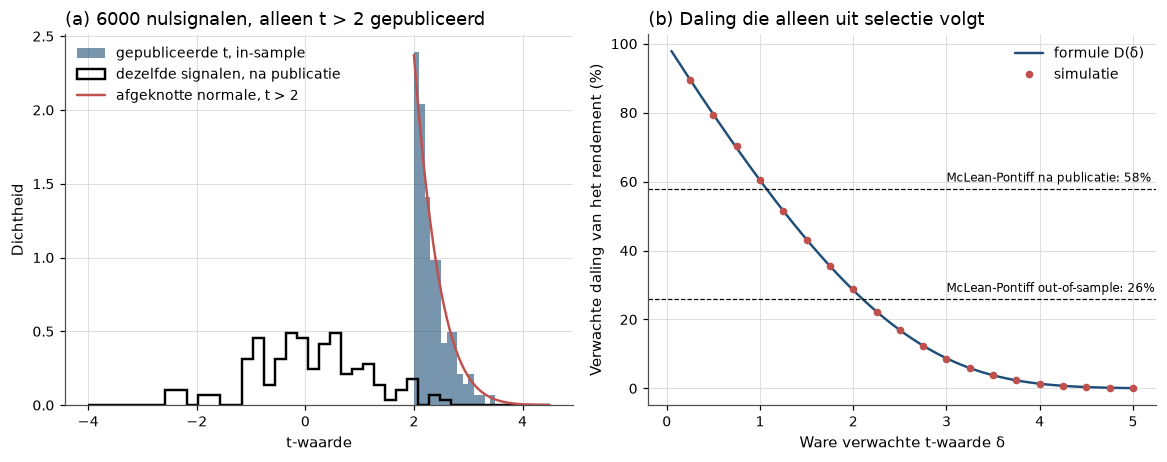

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
t_pub = null_field["in-sample"]["t"][published]
axes[0].hist(t_pub, bins=np.linspace(2, 4.5, 26), density=True, alpha=0.6, label="gepubliceerde t, in-sample")
axes[0].hist(null_field["post"]["t"][published], bins=np.linspace(-4, 4.5, 43), density=True,
             histtype="step", lw=1.6, color="black", label="dezelfde signalen, na publicatie")
grid = np.linspace(2, 4.5, 200)
axes[0].plot(grid, stats.norm.pdf(grid) / stats.norm.sf(c_pub), color=hap.plotting.COLORS[1],
             label="afgeknotte normale, t > 2")
axes[0].set_title("(a) 6000 nulsignalen, alleen t > 2 gepubliceerd")
axes[0].set_xlabel("t-waarde")
axes[0].set_ylabel("Dichtheid")
axes[0].legend()

fine = np.linspace(0.05, 5, 200)
axes[1].plot(fine, 100 * decline_formula(fine), label="formule D(δ)")
axes[1].plot(deltas, 100 * simulated_decline, "o", ms=4, label="simulatie")
for level, text in ((26, "McLean-Pontiff out-of-sample: 26%"), (58, "McLean-Pontiff na publicatie: 58%")):
    axes[1].axhline(level, color="black", lw=0.8, ls="--")
    axes[1].text(3.0, level + 2, text, fontsize=8)
axes[1].set_title("(b) Daling die alleen uit selectie volgt")
axes[1].set_xlabel("Ware verwachte t-waarde δ")
axes[1].set_ylabel("Verwachte daling van het rendement (%)")
axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

:::{figure} #cel-factor-zoo-selectie
:label: fig-factor-zoo-selectie
:width: 100%

Links: in een markt zonder anomalieën volgen de gepubliceerde $t$-waarden de afgeknotte
normale verdeling, en na publicatie liggen dezelfde signalen weer rond nul. Rechts: de
daling die puur uit de selectie $t > 2$ volgt, als functie van de ware sterkte van het
signaal. De 26% van McLean en Pontiff past bij signalen met een ware verwachte $t$ rond
2,1; hun 58% na publicatie zou, als alleen selectie meespeelde, signalen vereisen met een
ware verwachte $t$ rond één, die de drempel meestal niet eens halen.
:::

### (b) Empirical Bayes herstelt de ware premies

Nu een dierentuin met 300 signalen waarvan de helft geen premie heeft en de andere helft
premies $\alpha_i \sim \mathcal{N}(0{,}4\%;\ 0{,}3\%^2)$ per maand. De prior is dus níet
normaal, zodat we zien of de normale shrinkage van {prf:ref}`thm-factor-zoo-shrinkage`
robuust is. De signalen hebben steekproeven van 10 tot 50 jaar en volatiliteiten van 1,5%
tot 5% per maand; we trekken $\hat\alpha_i$ exact uit $\mathcal{N}(\alpha_i, s_i^2)$ en herhalen
het universum 500 keer.

In [7]:
def empirical_bayes(estimate, se, zero_mean=False):
    """Normal-normal empirical Bayes: posterior means and sds with the prior estimated by moments."""
    # TODO: naar hap.stats (empirical Bayes shrinkage)
    mu = 0.0 if zero_mean else float(np.mean(estimate))
    tau2 = max(float(np.mean((estimate - mu) ** 2) - np.mean(se**2)), 0.0)
    weight = tau2 / (tau2 + se**2)
    return mu + weight * (estimate - mu), np.sqrt(weight) * se, mu, np.sqrt(tau2)


n_signals, n_universes = 300, 500
metrics = []
for _ in range(n_universes):
    real = rng.random(n_signals) < 0.5
    alpha_true = np.where(real, rng.normal(0.004, 0.003, n_signals), 0.0)
    se = rng.uniform(0.015, 0.05, n_signals) / np.sqrt(rng.integers(120, 601, n_signals))
    alpha_hat = alpha_true + se * rng.standard_normal(n_signals)
    alpha_eb, _, _, _ = empirical_bayes(alpha_hat, se)
    selected = alpha_hat / se > c_pub
    metrics.append({
        "RMSE ruw": np.sqrt(np.mean((alpha_hat - alpha_true) ** 2)),
        "RMSE EB": np.sqrt(np.mean((alpha_eb - alpha_true) ** 2)),
        "bias na selectie, ruw": np.mean(alpha_hat[selected] - alpha_true[selected]),
        "bias na selectie, EB": np.mean(alpha_eb[selected] - alpha_true[selected]),
    })
metrics = pd.DataFrame(metrics)
last = pd.DataFrame({"waar": alpha_true, "ruw": alpha_hat, "EB": alpha_eb, "geselecteerd": selected})

(100 * metrics).describe().loc[["mean", "std"]].T.assign(
    **{"EB beter (fractie)": [np.mean(metrics["RMSE EB"] < metrics["RMSE ruw"])] * 2
       + [np.mean(metrics["bias na selectie, EB"].abs() < metrics["bias na selectie, ruw"].abs())] * 2}
).round(4)

,mean,std,EB beter (fractie)
RMSE ruw,0.1964,0.0111,1.000
RMSE EB,0.1541,0.0076,1.000
"bias na selectie, ruw",0.0822,0.0202,0.886
"bias na selectie, EB",-0.0366,0.0204,0.886


Empirical Bayes verlaagt de RMSE van 0,196 naar 0,154 procentpunt per maand, in alle 500
universa. Onder de signalen met $t > 2$ overschat de ruwe schatting de ware premie met
gemiddeld 0,082 procentpunt; de EB-schatting *onder*schat haar met 0,037 en zit in 89% van
de universa dichter bij nul. De tekenwissel is de prijs van een verkeerde prior: één
normale verdeling moet nulsignalen en premies rond 0,4% tegelijk beschrijven, en trekt de
laatste te hard terug. Motief 1 zit in de gewichten: signalen met een korte steekproef en
hoge volatiliteit worden het sterkst teruggetrokken.

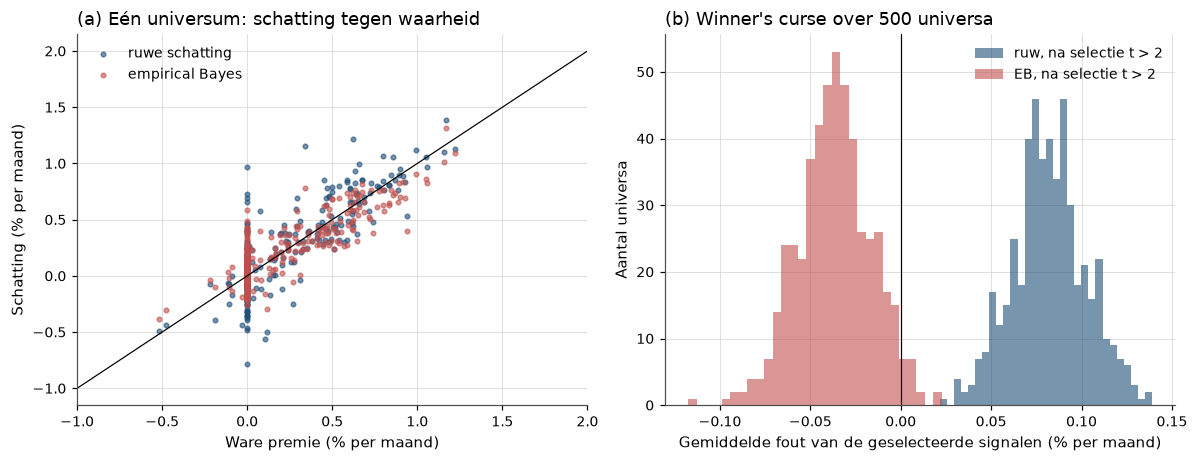

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for column, color in (("ruw", hap.plotting.COLORS[0]), ("EB", hap.plotting.COLORS[1])):
    axes[0].scatter(100 * last["waar"], 100 * last[column], s=9, alpha=0.6, color=color,
                    label=f"{'ruwe schatting' if column == 'ruw' else 'empirical Bayes'}")
lims = np.array([-1.0, 2.0])
axes[0].plot(lims, lims, color="black", lw=0.8)
axes[0].set_xlim(lims)
axes[0].set_title("(a) Eén universum: schatting tegen waarheid")
axes[0].set_xlabel("Ware premie (% per maand)")
axes[0].set_ylabel("Schatting (% per maand)")
axes[0].legend()

axes[1].hist(100 * metrics["bias na selectie, ruw"], bins=30, alpha=0.6, label="ruw, na selectie t > 2")
axes[1].hist(100 * metrics["bias na selectie, EB"], bins=30, alpha=0.6, label="EB, na selectie t > 2")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("(b) Winner's curse over 500 universa")
axes[1].set_xlabel("Gemiddelde fout van de geselecteerde signalen (% per maand)")
axes[1].set_ylabel("Aantal universa")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-factor-zoo-eb
:label: fig-factor-zoo-eb
:width: 100%

Links: ruwe schattingen van signalen met een grote standaardfout liggen ver van de
waarheid; empirical Bayes trekt ze naar het gemiddelde van de dierentuin en laat de
precies gemeten signalen vrijwel staan. Rechts: onder de signalen die $t > 2$ halen,
overschat de ruwe schatting de premie systematisch; de EB-schatting zit er in absolute
waarde dichter bij, maar onderschat, omdat de normale prior de mengverdeling van nulsignalen
en echte premies niet kan volgen.
:::

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** R. David McLean en Jeffrey Pontiff, *Does Academic Research Destroy Stock
Return Predictability?*, Journal of Finance 2016 {cite}`McLeanPontiff2016`; Campbell R.
Harvey, Yan Liu en Heqing Zhu, *... and the Cross-Section of Expected Returns*, Review of
Financial Studies 2016 {cite}`HarveyLiuZhu2016`; Kewei Hou, Chen Xue en Lu Zhang,
*Replicating Anomalies*, Review of Financial Studies 2020 {cite}`HouXueZhang2020`.

**Wat.** McLean en Pontiff, samenvatting: over 97 voorspellers zijn de rendementen "26%
lower out-of-sample and 58% lower post-publication". Harvey, Liu en Zhu, samenvatting en
bespreking van figuur 3: een nieuwe factor moet een $t$-waarde boven 3,0 halen; Bonferroni
eist 3,78 in 2012, BHY (5%) 2,78. Hou, Xue en Zhang, samenvatting: met NYSE-breekpunten en
value-weighted rendementen haalt 65% van 452 anomalieën $|t| \ge 1{,}96$ niet, en 82% niet
bij de drempel 2,78. Daarnaast tellen we hoeveel signalen een significante alfa houden
tegen FF5 {cite}`FamaFrench2015` plus momentum {cite}`Carhart1997`.

**Data hier.** Open Source Asset Pricing van {cite:t}`ChenZimmermann2022` via
`hap.data.osap()`: maandelijkse long-short-rendementen van de 212 signalen met categorie
`Predictor`, 1926-01 t/m 2024-12, en `hap.data.osap("signaldoc")` met per signaal het
begin- en eindjaar van de oorspronkelijke steekproef, het publicatiejaar en de
gerapporteerde $t$-waarde. Factoren: `"F-F_Research_Data_5_Factors_2x3"` en
`"F-F_Momentum_Factor"` via `hap.data.french`, 1963-07 t/m 2024-12.

**Verschil met het origineel.** McLean en Pontiff bouwden 97 voorspellers zelf, met data
tot 2013 en de publicatiedatum op maandniveau; wij hebben 212 signalen in de constructie
van Chen en Zimmermann, die de weging en kwantielen van het oorspronkelijke artikel
volgt, met elf jaar extra data. Periodes gaan per kalenderjaar: in-sample van begin- tot
eindjaar van de steekproef, out-of-sample tot en met het publicatiejaar, daarna
post-publicatie. Hou, Xue en Zhang gebruikten NYSE-breekpunten en value-weighted
rendementen voor álle anomalieën; OSAP niet, dus hun percentages zijn een referentie en
geen doel. Harvey, Liu en Zhu gebruikten de $t$-waarden uit de artikelen; wij passen hun
procedures toe op onze eigen $t$-waarden, met $M = 212$.

**Verwachte afwijking.** De rangorde van McLean en Pontiff moet identiek zijn: het
gemiddelde rendement is in-sample het hoogst, out-of-sample lager en na publicatie het
laagst; wijkt die volgorde af, dan zit er een fout in de code. Post-publicatierendementen
liggen ruim de helft lager dan in-sample, maar zijn gemiddeld positief. De drempel $t = 3$
schrapt een substantieel deel van de in-sample significante signalen. Na FF5 plus momentum
en een correctie voor meervoudig toetsen blijft een minderheid van de signalen over.
```

### (1) De verzwakking na publicatie

In [9]:
osap = hap_data.osap("portfolios")
doc = hap_data.osap("signaldoc")
doc = doc[doc["Cat.Signal"] == "Predictor"].set_index("signal")
for column in ["Year", "SampleStartYear", "SampleEndYear", "T-Stat"]:
    doc[column] = pd.to_numeric(doc[column], errors="coerce")

long = (osap.rename_axis(columns="signal").melt(ignore_index=False, value_name="r")
        .dropna().reset_index().join(doc[["SampleStartYear", "SampleEndYear", "Year"]], on="signal"))
year = long["date"].dt.year
long["periode"] = np.select(
    [year < long["SampleStartYear"], year <= long["SampleEndYear"], year <= long["Year"]],
    ["voor", "in-sample", "oos"], default="post")
long = long[long["periode"] != "voor"].reset_index(drop=True)

per_signal = long.groupby(["signal", "periode"])["r"].agg(["mean", "std", "count"]).unstack("periode")
means = per_signal["mean"][["in-sample", "oos", "post"]]
se_means = (per_signal["std"] / np.sqrt(per_signal["count"]))[["in-sample", "oos", "post"]]

period_table = pd.DataFrame({
    "signalen": means.notna().sum(),
    "gem. maanden": per_signal["count"][["in-sample", "oos", "post"]].mean(),
    "gem. rendement (% p.m.)": 100 * means.mean(),
    "SE (over signalen)": 100 * means.std(ddof=1) / np.sqrt(means.notna().sum()),
    "gem. SE per signaal": 100 * se_means.mean(),
    "t.o.v. in-sample": means.mean() / means["in-sample"].mean() - 1,
})
print(f"{osap.shape[1]} signalen, {len(long)} signaal-maanden; publicatiejaren "
      f"{int(doc['Year'].min())}-{int(doc['Year'].max())}")
period_table.round(3)

212 signalen, 136338 signaal-maanden; publicatiejaren 1973-2016


,signalen,gem. maanden,gem. rendement (% p.m.),SE (over signalen),gem. SE per signaal,t.o.v. in-sample
periode,,,,,,
in-sample,212,350.887,0.687,0.032,0.194,0.000
oos,212,54.623,0.409,0.053,0.475,-0.405
post,212,237.594,0.295,0.044,0.270,-0.571


In [10]:
def within(x, groups):
    """Demean a series within groups (the fixed-effects transformation)."""
    return x - x.groupby(groups).transform("mean")


def mp_regression(frame, extra=None):
    """Pooled OLS of returns (% p.m.) on OOS and POST dummies with signal fixed effects.

    Standard errors are clustered by month. `extra` adds further dummy columns.
    """
    # TODO: naar hap.stats (panel regression with fixed effects and clustered errors)
    y = within(100 * frame["r"], frame["signal"])
    X = pd.get_dummies(frame["periode"])[["oos", "post"]].astype(float)
    if extra is not None:
        X = X.join(extra)
    X = X.apply(within, groups=frame["signal"])
    coef, *_ = np.linalg.lstsq(X.to_numpy(), y.to_numpy(), rcond=None)
    resid = y.to_numpy() - X.to_numpy() @ coef
    bread = np.linalg.inv(X.T.to_numpy() @ X.to_numpy())
    scores = pd.DataFrame(X.to_numpy() * resid[:, None]).groupby(frame["date"].to_numpy()).sum().to_numpy()
    se = np.sqrt(np.diag(bread @ scores.T @ scores @ bread))
    return pd.DataFrame({"coef (% p.m.)": coef, "SE (cluster maand)": se, "t": coef / se}, index=X.columns)


mp = mp_regression(long).loc[["oos", "post"]]
in_sample_mean = 100 * means["in-sample"].mean()
mp["t.o.v. gem. in-sample"] = mp["coef (% p.m.)"] / in_sample_mean
mp.loc["post - oos (publicatie-effect)"] = [
    mp.loc["post", "coef (% p.m.)"] - mp.loc["oos", "coef (% p.m.)"], np.nan, np.nan,
    (mp.loc["post", "coef (% p.m.)"] - mp.loc["oos", "coef (% p.m.)"]) / in_sample_mean]
mp.round(3)

,coef (% p.m.),SE (cluster maand),t,t.o.v. gem. in-sample
oos,-0.247,0.064,-3.851,-0.359
post,-0.369,0.057,-6.494,-0.538
post - oos (publicatie-effect),-0.123,NaN,NaN,-0.179


De rangorde van McLean en Pontiff komt uit. Gemiddeld over de 212 signalen is het
long-short-rendement in-sample 0,69% per maand, tussen steekproefeinde en publicatie
0,41% (40% lager) en na publicatie 0,30% (57% lager), met standaardfouten over de
signalen van 0,03 tot 0,05 procentpunt. Na publicatie is het rendement dus nog steeds
duidelijk positief. De gepoolde regressie met vaste effecten per signaal geeft een daling
van 0,25 procentpunt out-of-sample ($t = -3{,}85$, 36% van het gemiddelde in-sample
rendement) en 0,37 procentpunt na publicatie ($t = -6{,}49$, 54%); het verschil, het
publicatie-effect, is 18%. De regressie weegt signalen naar hun aantal maanden, en komt
daarom iets anders uit dan de gewone gemiddelden. Tegenover 26%, 58% en 32% bij McLean en
Pontiff is onze daling na publicatie vergelijkbaar, maar ligt meer ervan al vóór publicatie.

Motief 1 staat in de kolom "gem. SE per signaal": in zijn tussenperiode van gemiddeld 55
maanden heeft een signaal een standaardfout van 0,48% per maand, groter dan het rendement
zelf. Alleen door over 212 signalen te middelen wordt de daling meetbaar.

### (2) De verdeling van $t$-waarden en de drempels van Harvey, Liu en Zhu

In [11]:
t_values = (means / se_means)
tests = {period: multiple_testing(t_values[period].dropna()).sum()
         for period in ["in-sample", "post"]}
threshold_table = pd.DataFrame(tests).rename(index={"naief": "naief |t| > 1.96"})
threshold_table.loc["aantal signalen"] = [t_values[p].notna().sum() for p in ["in-sample", "post"]]

M = int(t_values["in-sample"].notna().sum())
print(f"Bonferroni-drempel bij M = {M}: |t| > {stats.norm.isf(0.025 / M):.2f}; c(M) = {np.sum(1 / np.arange(1, M + 1)):.2f}")

reported = doc["T-Stat"].reindex(t_values.index)
both = reported.notna()
print(f"gerapporteerde t in het artikel beschikbaar voor {both.sum()} signalen; "
      f"rangcorrelatie met onze in-sample t: {stats.spearmanr(reported[both], t_values.loc[both, 'in-sample'])[0]:.2f}; "
      f"aandeel van onze in-sample t > 1.96 onder deze signalen: {np.mean(t_values.loc[both, 'in-sample'] > 1.96):.2f}")
threshold_table

Bonferroni-drempel bij M = 212: |t| > 3.68; c(M) = 5.94
gerapporteerde t in het artikel beschikbaar voor 188 signalen; rangcorrelatie met onze in-sample t: 0.62; aandeel van onze in-sample t > 1.96 onder deze signalen: 0.88


,in-sample,post
naief |t| > 1.96,186,66
|t| > 3,122,24
Bonferroni,85,11
Holm,93,11
BH,184,37
BHY,137,13
aantal signalen,212,212


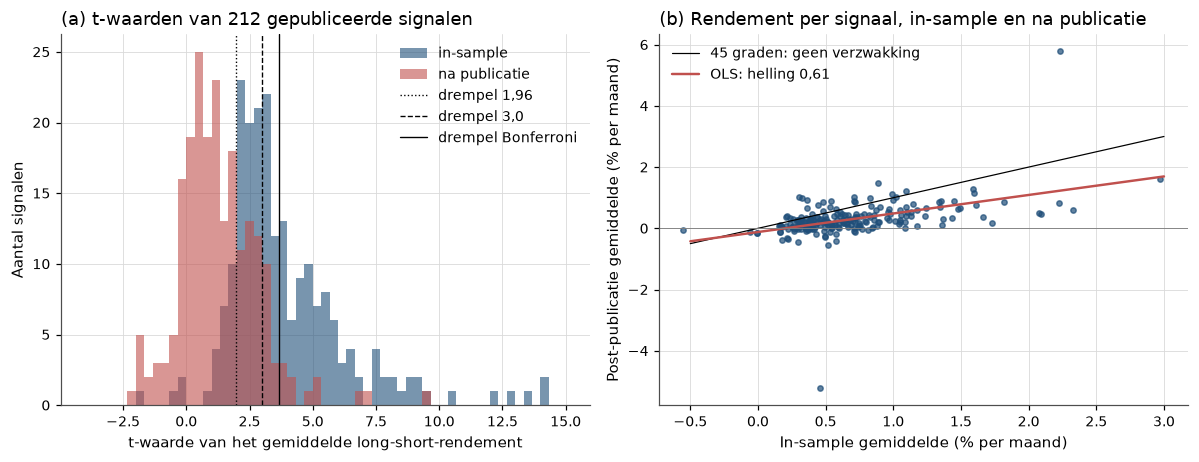

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
bins = np.linspace(-4, 15, 58)
axes[0].hist(t_values["in-sample"], bins=bins, alpha=0.6, label="in-sample")
axes[0].hist(t_values["post"], bins=bins, alpha=0.6, label="na publicatie")
for value, style, text in ((1.96, ":", "1,96"), (3.0, "--", "3,0"), (stats.norm.isf(0.025 / M), "-", "Bonferroni")):
    axes[0].axvline(value, color="black", lw=0.9, ls=style, label=f"drempel {text}")
axes[0].set_title("(a) t-waarden van 212 gepubliceerde signalen")
axes[0].set_xlabel("t-waarde van het gemiddelde long-short-rendement")
axes[0].set_ylabel("Aantal signalen")
axes[0].legend()

ok = means[["in-sample", "post"]].dropna()
axes[1].scatter(100 * ok["in-sample"], 100 * ok["post"], s=12, alpha=0.7)
lims = np.array([-0.5, 3.0])
axes[1].plot(lims, lims, color="black", lw=0.8, label="45 graden: geen verzwakking")
slope, intercept = np.polyfit(100 * ok["in-sample"], 100 * ok["post"], 1)
axes[1].plot(lims, intercept + slope * lims, color=hap.plotting.COLORS[1],
             label=f"OLS: helling {slope:.2f}".replace(".", ","))
axes[1].axhline(0, color="grey", lw=0.6)
axes[1].set_title("(b) Rendement per signaal, in-sample en na publicatie")
axes[1].set_xlabel("In-sample gemiddelde (% per maand)")
axes[1].set_ylabel("Post-publicatie gemiddelde (% per maand)")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-factor-zoo-osap
:label: fig-factor-zoo-osap
:width: 100%

Links: in-sample liggen de $t$-waarden ver rechts van elke drempel; na publicatie is de
verdeling naar links geschoven en haalt nog maar een klein deel de Bonferroni-drempel.
Rechts: signalen die in-sample sterk waren, blijven gemiddeld de sterkste, maar met een
helling van 0,61 en een negatieve intercept verliezen ze meer naarmate hun in-sample
rendement hoger was; de puntenwolk ligt gemiddeld ruim onder de 45-gradenlijn.
:::

In-sample haalt 186 van de 212 signalen $|t| > 1{,}96$ (88%). Voor de 188 signalen met een
gerapporteerde $t$ is de rangcorrelatie met onze in-sample $t$ 0,62, en ook daar haalt 88%
de drempel: replicatie in de oorspronkelijke constructie werkt grotendeels (het abstract
van {cite:t}`ChenZimmermann2022` konden we niet inzien, dus hun eigen percentages citeren
we niet). De 65% mislukkingen van Hou, Xue en Zhang zijn geen tegenspraak: zij wogen naar
marktwaarde met NYSE-breekpunten, OSAP volgt het artikel, voor 184 signalen gelijkgewogen.

De drempels van Harvey, Liu en Zhu schrappen een substantieel deel: met $t > 3$ vallen 64
van de 186 significante signalen af (34%). Bonferroni ($|t| > 3{,}68$ bij $M = 212$) houdt er
85 over, Holm 93, BHY 137 en Benjamini-Hochberg 184. Na publicatie haalt 66 signalen
$|t| > 1{,}96$, 24 $t > 3$ en 11 Bonferroni; die daling komt deels doordat de
post-publicatieperiode korter is.

### (3) Shrinkage: hoeveel overleeft, en hoeveel van de daling is statistiek?

Eerst de gemiddelden zelf, met een prior gecentreerd op nul zoals bij Jensen, Kelly en
Pedersen: we nemen aan dat een willekeurig signaal gemiddeld niets oplevert, en laten de
dierentuin zeggen hoe breed de premies verdeeld zijn.

In [13]:
est, se_in = means["in-sample"].to_numpy(), se_means["in-sample"].to_numpy()
post_mean, post_sd, _, tau_hat = empirical_bayes(est, se_in, zero_mean=True)
shrink = pd.DataFrame({"ruw": est, "EB": post_mean, "SE ruw": se_in, "SD posterior": post_sd,
                       "post-publicatie": means["post"].to_numpy()}, index=means.index)

survive = pd.Series({
    "tau (% p.m.)": 100 * tau_hat,
    "gem. krimpfactor": np.mean(tau_hat**2 / (tau_hat**2 + se_in**2)),
    "ruw: t > 1.96": np.sum(est / se_in > 1.96),
    "EB: posterior gem./SD > 1.96": np.sum(post_mean / post_sd > 1.96),
    "voorspelde daling door shrinkage": 1 - post_mean.mean() / est.mean(),
    "helling post op ruw": np.polyfit(shrink["ruw"], shrink["post-publicatie"], 1)[0],
    "helling post op EB": np.polyfit(shrink["EB"], shrink["post-publicatie"], 1)[0],
})
survive.round(3)

tau (% p.m.)                          0.799
gem. krimpfactor                      0.935
ruw: t > 1.96                       186.000
EB: posterior gem./SD > 1.96        181.000
voorspelde daling door shrinkage      0.089
helling post op ruw                   0.605
helling post op EB                    0.609
dtype: float64

De geschatte spreiding van premies is $\hat\tau = 0{,}80\%$ per maand, tegen een gemiddelde
standaardfout van 0,19%; de gemiddelde krimpfactor is daardoor 0,94 en de gemiddelden
krimpen maar 9%. Van de 186 ruw significante signalen blijven er 181 over, en als
voorspeller van post-publicatierendementen is de EB-schatting (helling 0,61) niet beter
dan de ruwe. Met een prior uit de gepubliceerde dierentuin verklaart statistiek dus minder
dan een kwart van de daling van 40% vóór publicatie, maar deze prior kent de
ongepubliceerde signalen niet.

Die prior is geschat op gepubliceerde signalen en daardoor te optimistisch
({prf:ref}`cor-factor-zoo-selectie`). Een zuiverder schatting gebruikt de $t$-waarden zoals
de artikelen ze rapporteerden, en neemt de selectie expliciet mee: stel dat de ware
verwachte $t$-waarden $\delta_i \sim \mathcal{N}(\mu_\delta, \omega^2)$ zijn en dat alleen
$t_i > 1{,}96$ werd gepubliceerd. Dan is $t_i$ afgeknot normaal met variantie $1 + \omega^2$,
we schatten $(\mu_\delta, \omega)$ met maximale aannemelijkheid, en
{prf:ref}`thm-factor-zoo-shrinkage` geeft $\E[\delta_i \mid t_i]$.

In [14]:
c_hurdle = 1.96
t_reported = doc["T-Stat"].dropna()
t_reported = t_reported[t_reported > c_hurdle]


def negative_loglik(params):
    """Truncated-normal likelihood of published t-statistics, t ~ N(mu, 1 + omega^2) given t > c."""
    mu, log_omega = params
    scale = np.sqrt(1 + np.exp(2 * log_omega))
    return -np.sum(stats.norm.logpdf(t_reported, mu, scale) - stats.norm.logsf(c_hurdle, mu, scale))


fit = optimize.minimize(negative_loglik, x0=[2.0, 0.0], method="Nelder-Mead")
mu_delta, omega = fit.x[0], np.exp(fit.x[1])
expected_delta = (mu_delta + omega**2 * t_reported) / (1 + omega**2)

truncation = pd.Series({
    "signalen met gerapporteerde t > 1.96": len(t_reported),
    "gem. gerapporteerde t": t_reported.mean(),
    "mu_delta": mu_delta, "omega": omega,
    "gem. E[delta | t]": expected_delta.mean(),
    "voorspelde daling door selectie": 1 - expected_delta.mean() / t_reported.mean(),
    "waargenomen daling out-of-sample": -period_table.loc["oos", "t.o.v. in-sample"],
    "waargenomen daling na publicatie": -period_table.loc["post", "t.o.v. in-sample"],
    "convergentie": fit.success,
})
truncation.round(3)

signalen met gerapporteerde t > 1.96      183
gem. gerapporteerde t                   4.685
mu_delta                               -7.355
omega                                   6.131
gem. E[delta | t]                       4.373
voorspelde daling door selectie         0.067
waargenomen daling out-of-sample        0.405
waargenomen daling na publicatie        0.571
convergentie                                1
dtype: object

Van de gerapporteerde $t$-waarden liggen er 183 boven 1,96, met een gemiddelde van 4,69.
De schatting convergeert naar $\hat\mu_\delta = -7{,}4$ en $\hat\omega = 6{,}1$: de
rechterstaart van een zeer brede verdeling ver links van nul. Als beschrijving van de
geprobeerde signalen is dat ongeloofwaardig (onderzoekers kiezen het teken zelf), en het
laat zien hoe slecht de ligging uit een afgeknotte steekproef te schatten is. Voor de
posterior telt vooral het gewicht $\hat\omega^2/(1 + \hat\omega^2) = 0{,}97$: de verwachte
ware $t$ is gemiddeld 4,37, een voorspelde daling door selectie van 7%.

Beide benaderingen geven hetzelfde: een publicatiedrempel van 1,96 verklaart zo'n 7 tot 9%
van de daling van 40% vóór publicatie, terwijl 26% volgens [](#ex-factor-zoo-1) ware
$t$-waarden rond 2,1 zou vereisen. Overblijvende verklaringen: gerapporteerde $t$-waarden
zijn sterker opgeblazen dan afknotting beschrijft (de ongepubliceerde varianten van
Harvey, Liu en Zhu), de tussenperiode bevat al arbitrage op werkdocumenten, of
anomalierendementen dalen in het algemeen door de tijd ([](#ex-factor-zoo-2)).

### (4) Alfa's ten opzichte van FF5 plus momentum

In [15]:
factors = hap_data.french("F-F_Research_Data_5_Factors_2x3").join(hap_data.french("F-F_Momentum_Factor"))
factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]
sample = osap.index.intersection(factors.dropna().index)
R_ls, F_six = osap.loc[sample], factors.loc[sample, factor_cols].to_numpy()


def alpha_tstat(y, F):
    """OLS intercept and homoskedastic t-statistic of y on F, dropping missing months of y."""
    ok = ~np.isnan(y)
    X = np.column_stack([np.ones(ok.sum()), F[ok]])
    coef, *_ = np.linalg.lstsq(X, y[ok], rcond=None)
    resid = y[ok] - X @ coef
    se = np.sqrt(resid @ resid / (ok.sum() - X.shape[1]) * np.linalg.inv(X.T @ X)[0, 0])
    return coef[0], coef[0] / se


after_pub = pd.DataFrame(sample.year.to_numpy()[:, None] > doc.loc[R_ls.columns, "Year"].to_numpy()[None, :],
                         index=sample, columns=R_ls.columns)
alphas = {}
for name, frame in {"1963-2024": R_ls, "na publicatie": R_ls.where(after_pub)}.items():
    values = np.array([alpha_tstat(frame[s].to_numpy(dtype=float), F_six) for s in frame.columns])
    alphas[name] = pd.DataFrame(values, index=frame.columns, columns=["alfa", "t"])

alpha_tests = {}
for name, a in alphas.items():
    rejected = multiple_testing(a["t"]).set_index(a.index)
    alpha_tests[name] = rejected.sum()
    alpha_tests[f"{name}, alfa > 0"] = rejected[a["alfa"] > 0].sum()
alpha_table = pd.DataFrame(alpha_tests)
alpha_table.loc["gem. alfa (% p.m.)"] = [100 * alphas[k.split(",")[0]]["alfa"].mean() for k in alpha_table.columns]
alpha_table.round(3)

,1963-2024,"1963-2024, alfa > 0",na publicatie,"na publicatie, alfa > 0"
naief,167.000,164.000,90.0,89.0
|t| > 3,123.000,123.000,36.0,36.0
Bonferroni,99.000,99.000,10.0,10.0
Holm,106.000,106.000,11.0,11.0
BH,161.000,159.000,62.0,62.0
BHY,131.000,130.000,15.0,15.0
gem. alfa (% p.m.),0.416,0.416,0.3,0.3


Over 1963–2024 heeft 167 van de 212 signalen een alfa met $|t| > 1{,}96$ ten opzichte van
FF5 plus momentum, 164 daarvan positief; de gemiddelde alfa is 0,42% per maand, nauwelijks
lager dan het ruwe rendement. Na correctie blijven er 99 over bij Bonferroni, 106 bij Holm,
131 bij BHY en 161 bij Benjamini-Hochberg. Na publicatie zijn het er 10 (Bonferroni), 11
(Holm), 15 (BHY) en 62 (Benjamini-Hochberg), bij een gemiddelde alfa van 0,30% per maand.

Dit wijkt deels af van het replicatieblok. Na publicatie blijft bij elke procedure een
minderheid over, maar over de hele periode alleen bij Bonferroni (99, 47%) en op het
randje bij Holm (106, precies de helft); bij BHY en Benjamini-Hochberg houdt een
meerderheid een significante alfa. Drie redenen liggen voor de hand: 1963–2024 bevat de
in-sample jaren waarop de signalen zijn geselecteerd; de meeste OSAP-portefeuilles zijn
gelijkgewogen en worden gedreven door kleine aandelen die value-weighted factoren slecht
bereiken; en B/M, winstgevendheid en momentum zitten zelf in de dierentuin. Opvallend is
dat de gemiddelde post-publicatie-alfa van 0,30% gelijk is aan het ruwe
post-publicatierendement: de zes factoren verklaren niet wat er na publicatie over is.

## Wat er brak, en wat daarna kwam

**Wat het kader verklaart.** Meervoudig toetsen, publicatieselectie en shrinkage maken van
"is dit significant?" een vraag waarvan het antwoord van het aantal pogingen afhangt, en
dat antwoord is streng maar niet vernietigend: 88% van de 212 voorspellers haalt in de
oorspronkelijke constructie $|t| > 1{,}96$ en BHY houdt er 137 over. De replicatiecrisis is
grotendeels een verschil in weging en drempels, zoals Chen en Zimmermann en Jensen, Kelly
en Pedersen betoogden, en vijf of zes factoren uit de boekhouding van de onderneming
beschrijven een groot deel van de cross-sectie.

**Waar het breekt.** Bij de verzwakking. In onze replicatie ligt het gemiddelde
rendement na publicatie 57% onder het in-sample niveau, en na publicatie overleeft nog 11
van de 212 signalen Bonferroni. Publicatieselectie verklaart daar met beide
shrinkage-benaderingen hoogstens een tiende van, en de zes factoren van FF5 plus momentum
verklaren het gemiddelde rendement dat na publicatie over is niet. Het kader zegt hoeveel
we moeten wantrouwen, maar niet waarom de premies kleiner worden.

**Risico of vergissing?** McLean en Pontiff kozen zelf: "Our findings suggest that investors
learn about mispricing from academic publications" {cite}`McLeanPontiff2016`. Dat is de
Yale-lezing. De Chicago-lezing is even consistent: kenmerken meten blootstelling aan
risico, en zodra meer kapitaal (factorfondsen, smart beta) dat risico wil dragen, daalt de
prijs ervan; een lagere premie is dan betere risicodeling. Daarnaast staat datamining, de
lezing waarin er nooit iets was. Scheiden zou kunnen met een daling die precies samenvalt
met de publicatiedatum, maar [](#ex-factor-zoo-2) laat zien dat die in onze data niet te
onderscheiden is van een algemene daling door de tijd, en die kan zelf arbitrage of
risicodeling zijn. Voor een belegger is het Santa-Clara's vraag: "Everything I made that
lasted came from bearing risk that was priced. Everything I lost came from thinking I knew
something the price did not" {cite}`SantaClara2026`. Wie in 2015 een factorfonds kocht,
kocht een van beide, en de data zeggen niet welke.

**Wat er daarna kwam.** Als honderden ruisige signalen elk een beetje informatie bevatten, ligt
het voor de hand ze niet één voor één te toetsen maar door een machine te laten
combineren: [](#06-35-machine-learning).

## Oefeningen

:::{exercise}
:label: ex-factor-zoo-1

**Hoeveel van de daling is selectie?** Neem {prf:ref}`thm-factor-zoo-truncatie` met
$c = 2$.

1. Leid $\E[t \mid t > c] = \delta + \lambda(c - \delta)$ af en laat zien dat
   $\lambda(x) > x$ voor elke $x$, zodat de verwachte gepubliceerde $t$ altijd boven $c$ ligt.
2. Voor welke ware verwachte $t$-waarde $\delta$ is de verwachte daling precies 26%? En 58%?
3. De in-sample $t$-waarden van de OSAP-signalen zijn gemiddeld bijna vier. Welke daling
   voorspelt [](#eq-factor-zoo-daling) als *alle* signalen $\delta = 4$ hebben, en wat zegt dat
   over de verklaring van McLean en Pontiffs 26%?
:::

:::{solution} ex-factor-zoo-1
:class: dropdown

**(1)** Zie het bewijs van {prf:ref}`thm-factor-zoo-truncatie`. Dat $\lambda(x) > x$ volgt
uit $\E[z \mid z > x] > x$: een verwachting over een verzameling waarop $z > x$ ligt
strikt boven $x$.

**(2) en (3)**

In [16]:
delta_58 = optimize.brentq(lambda d: decline_formula(d) - 0.58, 0.01, 5.0)
print(f"daling 26%: delta = {delta_26:.3f};  daling 58%: delta = {delta_58:.3f}")
print(f"daling bij delta = 4: {decline_formula(4.0):.3%};  lambda(x) > x op [-3, 3]: "
      f"{np.all(inverse_mills(np.linspace(-3, 3, 61)) > np.linspace(-3, 3, 61))}")

daling 26%: delta = 2.097;  daling 58%: delta = 1.066
daling bij delta = 4: 1.362%;  lambda(x) > x op [-3, 3]: True


Een daling van 26% vereist ware verwachte $t$-waarden rond 2,1, en 58% waarden rond 1. Bij
$\delta = 4$ voorspelt selectie een daling van 1,4%. De oefening laat zien dat McLean en
Pontiffs 26% alleen "statistiek" is als de gerapporteerde $t$-waarden flink zijn
opgeblazen, door varianten en specificatiekeuzes die de drempel $t > 2$ niet vangt.
:::

:::{exercise}
:label: ex-factor-zoo-2

**Publicatie of kalendertijd?** Breid [](#eq-factor-zoo-mp-regressie) uit met vaste
effecten voor vijfjaarsperioden (1926–1930, 1931–1935, ...), zodat een algemene daling van
anomalierendementen door de tijd niet als publicatie-effect wordt geteld.

1. Schat de regressie met `mp_regression(long, extra=...)`.
2. Hoe veranderen de coëfficiënten op OOS en POST, en wat identificeert ze nu nog?
:::

:::{solution} ex-factor-zoo-2
:class: dropdown

In [17]:
five_year = pd.get_dummies((long["date"].dt.year // 5) * 5, prefix="periode", dtype=float)
with_time = mp_regression(long, extra=five_year.iloc[:, 1:]).loc[["oos", "post"]]
with_time.assign(**{"t.o.v. gem. in-sample": with_time["coef (% p.m.)"] / in_sample_mean}).round(3)

,coef (% p.m.),SE (cluster maand),t,t.o.v. gem. in-sample
oos,-0.291,0.058,-5.052,-0.423
post,-0.284,0.087,-3.264,-0.413


Met vaste effecten voor vijfjaarsperioden is de daling out-of-sample 0,29 procentpunt
($t = -5{,}05$, 42% van het in-sample gemiddelde) en na publicatie 0,28 ($t = -3{,}26$, 41%).
Het publicatie-effect van 18% verdwijnt. OOS en POST worden nu alleen geïdentificeerd
doordat signalen in dezelfde vijf jaar in verschillende fasen zitten. De oefening laat
zien dat de decompositie van McLean en Pontiff gevoelig is voor wat kalendertijd mag
verklaren: in onze data overschaduwt een algemene daling van anomalierendementen de
publicatiedatum.
:::

:::{exercise}
:label: ex-factor-zoo-3

**De drempel van 3 in jaren.** Een long-short-signaal heeft een ware Sharpe-ratio van 0,5
per jaar.

1. Laat zien dat de verwachte $t$-waarde na $T$ jaar $0{,}5\sqrt{T}$ is. Hoeveel jaar is
   nodig voor een verwachte $t$ van 1,96, en hoeveel voor 3,0?
2. Harvey, Liu en Zhu rapporteren een Bonferroni-drempel van 3,78 in 2012 bij een
   tweezijdig niveau van 5%. Welk aantal toetsen $M$ impliceert dat, en hoe verhoudt het zich
   tot hun 316 factoren?
3. Hoeveel jaar data is dan nodig voor $t = 3{,}78$?
:::

:::{solution} ex-factor-zoo-3
:class: dropdown

**(1)** Met $T$ jaar is $\hat\mu/(\hat\sigma/\sqrt T) \approx \sqrt{T}\,\mu/\sigma$. Voor
$t = 1{,}96$ is $T = (1{,}96/0{,}5)^2 = 15{,}4$ jaar; voor $t = 3$ is $T = 36$ jaar.

**(2) en (3)**

In [18]:
p_378 = 2 * stats.norm.sf(3.78)
print(f"tweezijdige p bij t = 3.78: {p_378:.2e}; impliciete M = 0.05 / p = {0.05 / p_378:.0f}")
print(f"jaren voor t = 1.96, 3.00, 3.78: {[round((t / 0.5)**2, 1) for t in (1.96, 3.0, 3.78)]}")

tweezijdige p bij t = 3.78: 1.57e-04; impliciete M = 0.05 / p = 319
jaren voor t = 1.96, 3.00, 3.78: [15.4, 36.0, 57.2]


Een drempel van 3,78 komt overeen met ruim 300 toetsen, in lijn met hun catalogus van 316
factoren. Een signaal met een respectabele Sharpe-ratio van 0,5 heeft dan 57 jaar data
nodig om de drempel naar verwachting te halen, meer dan de Amerikaanse boekhouddata lang
is. De oefening laat zien waarom de factor zoo en het 2%-motief hetzelfde probleem zijn:
een strengere drempel beschermt tegen toeval, maar maakt veel echte premies onmeetbaar.
:::